In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter

# Load data
spotify_wb = pd.read_csv('../../data/processed/spotify-wb-cleaned.csv')

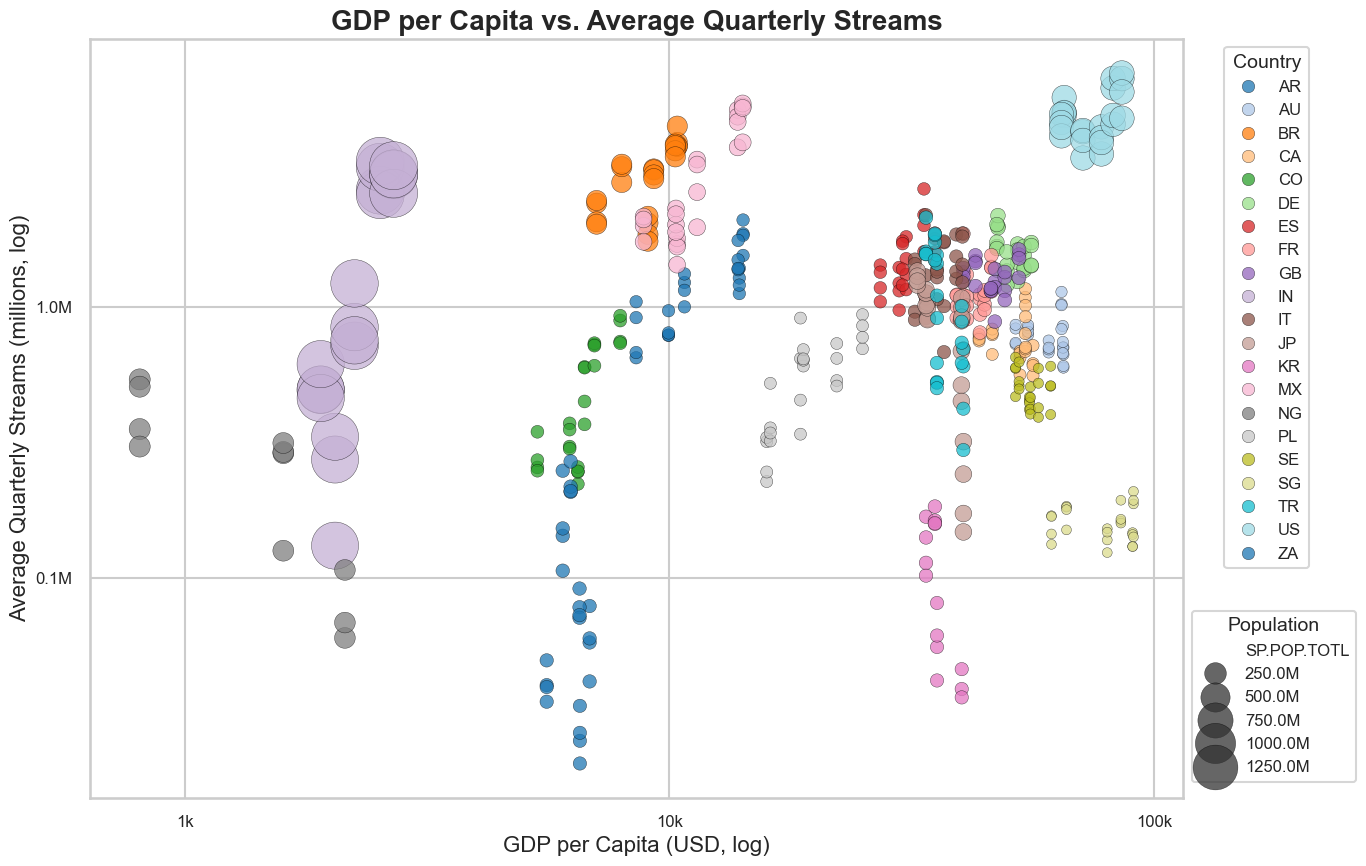

In [64]:
# Ensure numeric types
spotify_wb['streams'] = pd.to_numeric(spotify_wb['streams'], errors='coerce')
spotify_wb['NY.GDP.PCAP.CD'] = pd.to_numeric(spotify_wb['NY.GDP.PCAP.CD'], errors='coerce')

# GDP per capita vs. average quarterly streams
avg_streams = spotify_wb.groupby(
    ['country_code', 'year', 'quarter', 'NY.GDP.PCAP.CD']
).agg({'streams':'mean', 'SP.POP.TOTL':'first'}).reset_index()

plt.figure(figsize=(14,9))

# Palette for countries
palette = sns.color_palette("tab20", n_colors=avg_streams['country_code'].nunique())

# Scatter plot
scatter = sns.scatterplot(
    data=avg_streams,
    x='NY.GDP.PCAP.CD',
    y='streams',
    size='SP.POP.TOTL',
    hue='country_code',
    palette=palette,
    sizes=(50, 1200),
    alpha=0.75,
    edgecolor="black",
    linewidth=0.3
)

# Log axes
plt.xscale('log')
plt.yscale('log')

# Format axes tick labels
fmt_thousands = ticker.FuncFormatter(lambda x, pos: f'{x/1000:.0f}k')
fmt_millions  = ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')

plt.gca().xaxis.set_major_formatter(fmt_thousands)   # GDP in thousands
plt.gca().yaxis.set_major_formatter(fmt_millions)    # Streams in millions

# ---------------------------
# 🔹 Titles and labels with larger fonts
# ---------------------------
plt.xlabel('GDP per Capita (USD, log)', fontsize=16)
plt.ylabel('Average Quarterly Streams (millions, log)', fontsize=16)
plt.title('GDP per Capita vs. Average Quarterly Streams', fontsize=20, fontweight='bold')

# Increase tick size
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# ---------------------------
# 🔹 Separate legends for color + size
# ---------------------------
handles, labels = scatter.get_legend_handles_labels()
n_countries = avg_streams['country_code'].nunique()

country_handles = handles[1 : 1 + n_countries]
country_labels  = labels[1 : 1 + n_countries]

size_handles = handles[1 + n_countries :]
size_labels  = labels[1 + n_countries :]

# Format bubble size labels into K/M
def format_size_label(lbl):
    try:
        val = float(lbl)
        if val > 1e6:
            return f"{val/1e6:.1f}M"
        elif val > 1e3:
            return f"{val/1e3:.0f}k"
        else:
            return f"{val:.0f}"
    except:
        return lbl

size_labels_fmt = [format_size_label(lbl) for lbl in size_labels]

# Country legend
legend1 = plt.legend(
    country_handles,
    country_labels,
    title="Country",
    title_fontsize=14,
    fontsize=12,
    bbox_to_anchor=(1.03, 1),
    loc='upper left'
)
plt.gca().add_artist(legend1)

# Population legend
plt.legend(
    size_handles,
    size_labels_fmt,
    title="Population",
    title_fontsize=14,
    fontsize=12,
    bbox_to_anchor=(1, 0.01),
    loc='lower left'
)

plt.tight_layout()
plt.show()

C:\Users\HVNLY\AppData\Local\Temp\ipykernel_39940\2269384511.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='GDP_quartile', y='is_new', data=turnover, palette="Blues")


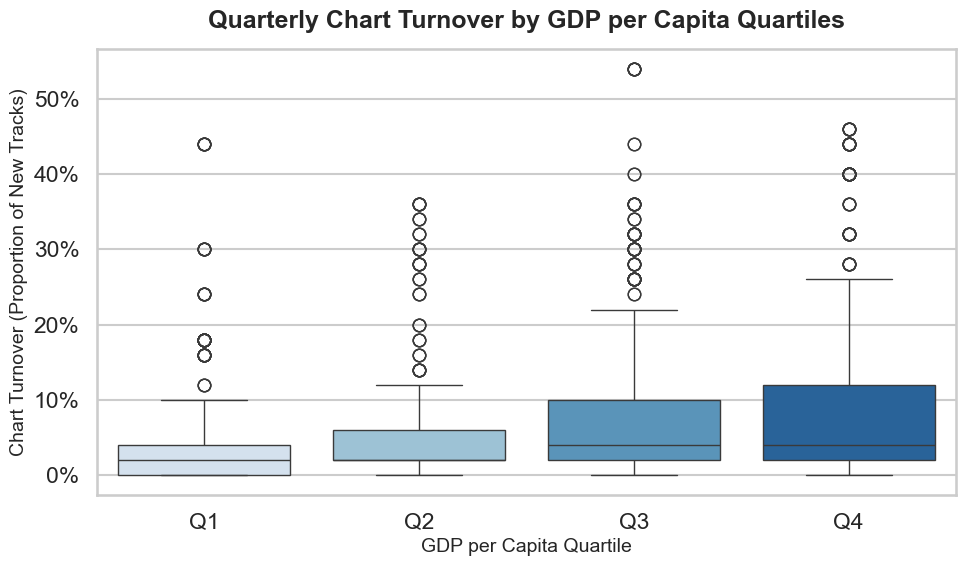

In [66]:
# compute chart turnover: proportion of new tracks
spotify_wb['is_new'] = spotify_wb['weeks_on_chart'] == 1
turnover = spotify_wb.groupby(['country_name','year','quarter'])['is_new'].mean().reset_index()
turnover = turnover.merge(spotify_wb[['country_name','NY.GDP.PCAP.CD']].drop_duplicates(), on='country_name', how='left')
turnover['GDP_quartile'] = pd.qcut(turnover['NY.GDP.PCAP.CD'], 4, labels=['Q1','Q2','Q3','Q4'])

plt.figure(figsize=(10,6))
sns.set_style("whitegrid")
sns.set_context("talk")

sns.boxplot(x='GDP_quartile', y='is_new', data=turnover, palette="Blues")

plt.xlabel('GDP per Capita Quartile', fontsize=14)
plt.ylabel('Chart Turnover (Proportion of New Tracks)', fontsize=14)
plt.title('Quarterly Chart Turnover by GDP per Capita Quartiles', fontsize=18, fontweight='bold', pad=15)

# format y-axis as percentage
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

plt.tight_layout()
plt.show()

C:\Users\HVNLY\AppData\Local\Temp\ipykernel_39940\1727505605.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_plot = foreign_avg.groupby('GDP_decile')['foreign'].mean().reset_index()


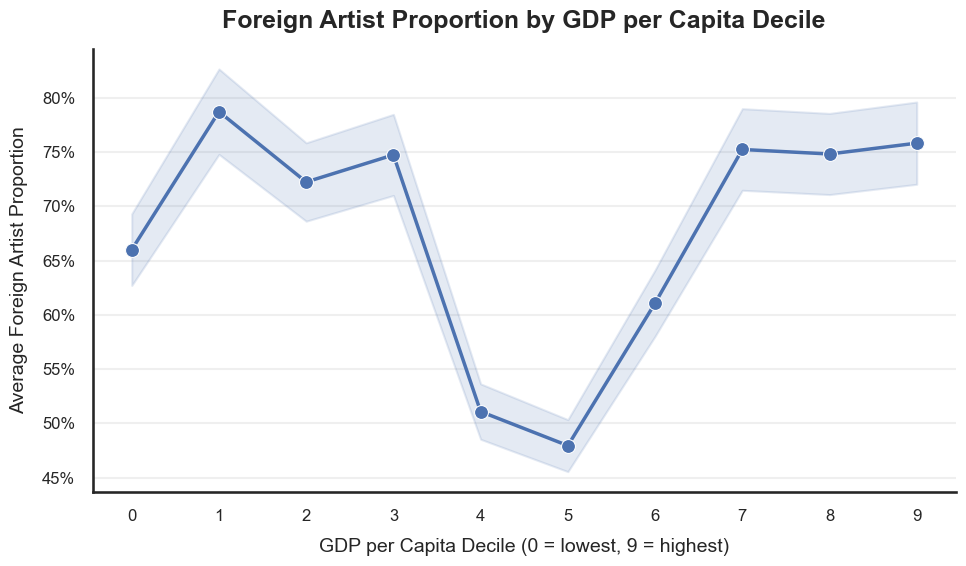

In [67]:
# Compute average foreign proportion per country per year
foreign_avg = spotify_wb.groupby(
    ['country_name','year','NY.GDP.PCAP.CD']
).agg({'foreign':'mean'}).reset_index()

# Create GDP deciles
foreign_avg['GDP_decile'] = pd.qcut(
    foreign_avg['NY.GDP.PCAP.CD'], 
    10, 
    duplicates='drop'
)

# Group by decile to get mean foreign proportion
decile_plot = foreign_avg.groupby('GDP_decile')['foreign'].mean().reset_index()
decile_plot['GDP_decile_num'] = decile_plot['GDP_decile'].cat.codes

# ---------------------------
# 🔹 Elegant line plot
# ---------------------------
plt.figure(figsize=(10,6))

# Use a muted palette
sns.set_palette("Set2")
sns.set_style("white")  # clean background
sns.set_context("talk")  # larger readable fonts

ax = sns.lineplot(
    data=decile_plot,
    x='GDP_decile_num',
    y='foreign',
    marker='o',
    linewidth=2.5,
    markersize=10,
    color="#4C72B0",   # muted blue
)

# Add a subtle shaded area for variability (optional)
# Here we can mock a small band for demonstration purposes
ax.fill_between(
    decile_plot['GDP_decile_num'], 
    decile_plot['foreign']*0.95, 
    decile_plot['foreign']*1.05, 
    color="#4C72B0", 
    alpha=0.15
)

# Title and labels
ax.set_title('Foreign Artist Proportion by GDP per Capita Decile',
             fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('GDP per Capita Decile (0 = lowest, 9 = highest)', fontsize=14, labelpad=10)
ax.set_ylabel('Average Foreign Artist Proportion', fontsize=14, labelpad=10)

# Format y-axis as percentages
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

# X-axis ticks as deciles
ax.set_xticks(decile_plot['GDP_decile_num'])
ax.set_xticklabels(decile_plot['GDP_decile_num'], fontsize=12)
ax.tick_params(axis='y', labelsize=12)

# Remove top and right spines for elegance
sns.despine()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()